In [1]:
%matplotlib inline
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
FEATURES_PATH = PROJECT_ROOT / "dataset" / "features_3.0_sec.json"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)
print(FEATURES_PATH)

C:\Users\Muham\Desktop\Data (1)\music-genre-classification
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\dataset\features_3.0_sec.json


In [2]:
with FEATURES_PATH.open("r", encoding="utf-8") as fp:
    data = json.load(fp)

X = np.array(data["mfcc"], dtype=np.float32)
y = np.array(data["genre_num"], dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=SEED, stratify=y_train)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (5594, 132, 13) y_train: (5594,)
X_val: (1399, 132, 13) y_val: (1399,)
X_test: (2997, 132, 13) y_test: (2997,)


In [3]:
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import BatchNormalization, Conv2D, Dense, Dropout, Flatten, MaxPooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

X_train_cnn = X_train[..., np.newaxis]
X_val_cnn = X_val[..., np.newaxis]
X_test_cnn = X_test[..., np.newaxis]
input_shape = X_train_cnn.shape[1:]
print(input_shape)

(132, 13, 1)


In [4]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history.history["accuracy"], label="training accuracy")
    axes[0].plot(history.history["val_accuracy"], label="validation accuracy")
    axes[0].set_title(title + " - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(history.history["loss"], label="training loss")
    axes[1].plot(history.history["val_loss"], label="validation loss")
    axes[1].set_title(title + " - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


def show_confusion_matrix(model, X_current, y_current, title):
    y_pred = np.argmax(model.predict(X_current, verbose=0), axis=1)
    cm = confusion_matrix(y_current, y_pred)
    fig, ax = plt.subplots(figsize=(9, 9))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRES)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(classification_report(y_current, y_pred, target_names=GENRES, zero_division=0))
    return y_pred

In [5]:
def build_cnn_baseline(input_shape):
    model = Sequential(name="cnn_baseline")
    model.add(Conv2D(32, 3, activation="relu", input_shape=input_shape))
    model.add(MaxPooling2D(3, strides=(2, 2), padding="same"))
    model.add(Conv2D(64, 3, activation="relu"))
    model.add(MaxPooling2D(3, strides=(2, 2), padding="same"))
    model.add(Conv2D(64, 2, activation="relu"))
    model.add(MaxPooling2D(2, strides=(2, 2), padding="same"))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(Dense(len(GENRES), activation="softmax"))
    return model


def build_cnn_best_candidate(input_shape):
    model = Sequential(name="cnn_best_candidate")
    model.add(Conv2D(32, 3, activation="relu", input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(3, strides=(2, 2), padding="same"))
    model.add(Dropout(0.2))
    model.add(Conv2D(64, 3, activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(3, strides=(2, 2), padding="same"))
    model.add(Dropout(0.1))
    model.add(Conv2D(64, 2, activation="relu"))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2, strides=(2, 2), padding="same"))
    model.add(Dropout(0.1))
    model.add(Flatten())
    model.add(Dense(128, activation="relu"))
    model.add(Dropout(0.5))
    model.add(Dense(64, activation="relu", kernel_regularizer=l2(0.001)))
    model.add(Dense(len(GENRES), activation="softmax"))
    return model

Onceki model - CNN baseline


C:\Users\Muham\Desktop\Data (1)\music-genre-classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 130, 11, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 65, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 63, 4, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 2, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 31, 1, 64)      │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,514 (396.54 KB)

...

Epoch 56/100


88/88 - 1s - 13ms/step - accuracy: 0.9457 - loss: 0.2340 - val_accuracy: 0.6984 - val_loss: 0.9824 - learning_rate: 6.2500e-06


Epoch 57/100


88/88 - 1s - 15ms/step - accuracy: 0.9464 - loss: 0.2328 - val_accuracy: 0.6984 - val_loss: 0.9830 - learning_rate: 6.2500e-06


Training accuracy: 0.9106
Validation accuracy: 0.7005
Test accuracy: 0.6723
Loss: 0.3071
Validation loss: 1.0059
Test loss: 1.0449


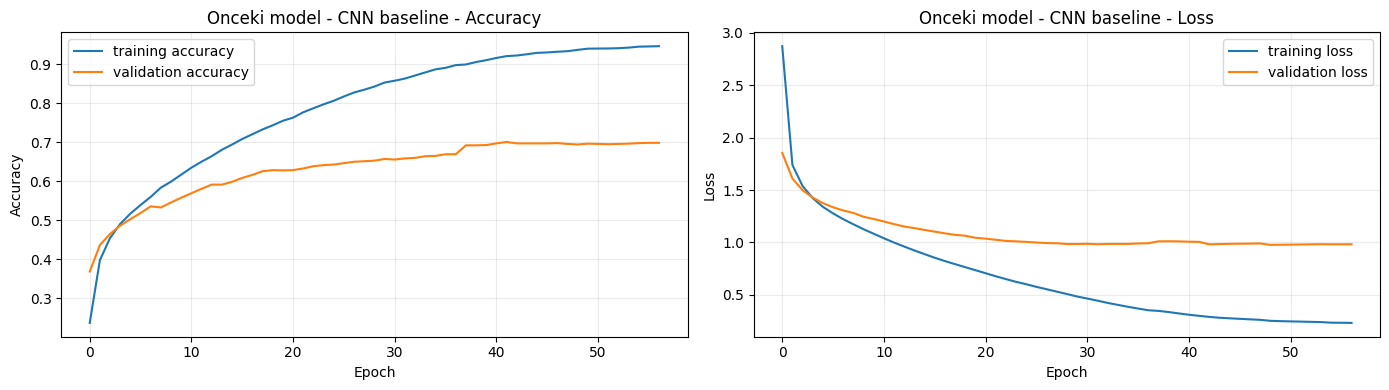

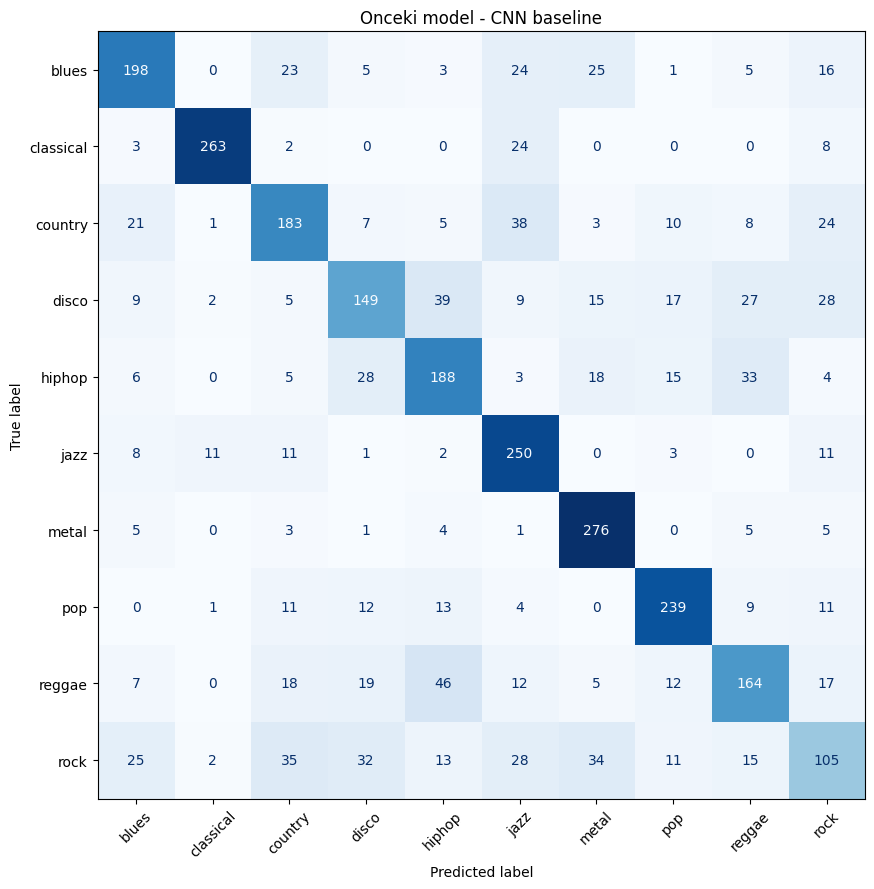

              precision    recall  f1-score   support

       blues       0.70      0.66      0.68       300
   classical       0.94      0.88      0.91       300
     country       0.62      0.61      0.61       300
       disco       0.59      0.50      0.54       300
      hiphop       0.60      0.63      0.61       300
        jazz       0.64      0.84      0.72       297
       metal       0.73      0.92      0.82       300
         pop       0.78      0.80      0.79       300
      reggae       0.62      0.55      0.58       300
        rock       0.46      0.35      0.40       300

    accuracy                           0.67      2997
   macro avg       0.67      0.67      0.67      2997
weighted avg       0.67      0.67      0.67      2997

En basarili model - CNN batchnorm/dropout


C:\Users\Muham\Desktop\Data (1)\music-genre-classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "cnn_best_candidate"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 130, 11, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 130, 11, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 65, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 65, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 63, 4, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 63, 4, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 2, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 2, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 31, 1, 64)      │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 31, 1, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176,010 (687.54 KB)

...

Epoch 99/100


88/88 - 3s - 34ms/step - accuracy: 0.7408 - loss: 0.7921 - val_accuracy: 0.6855 - val_loss: 1.0861 - learning_rate: 6.2500e-06


Epoch 100/100


88/88 - 3s - 34ms/step - accuracy: 0.7347 - loss: 0.8089 - val_accuracy: 0.6848 - val_loss: 1.0853 - learning_rate: 3.1250e-06


Training accuracy: 0.7277
Validation accuracy: 0.6855
Test accuracy: 0.6657
Loss: 0.8365
Validation loss: 1.0857
Test loss: 1.0901


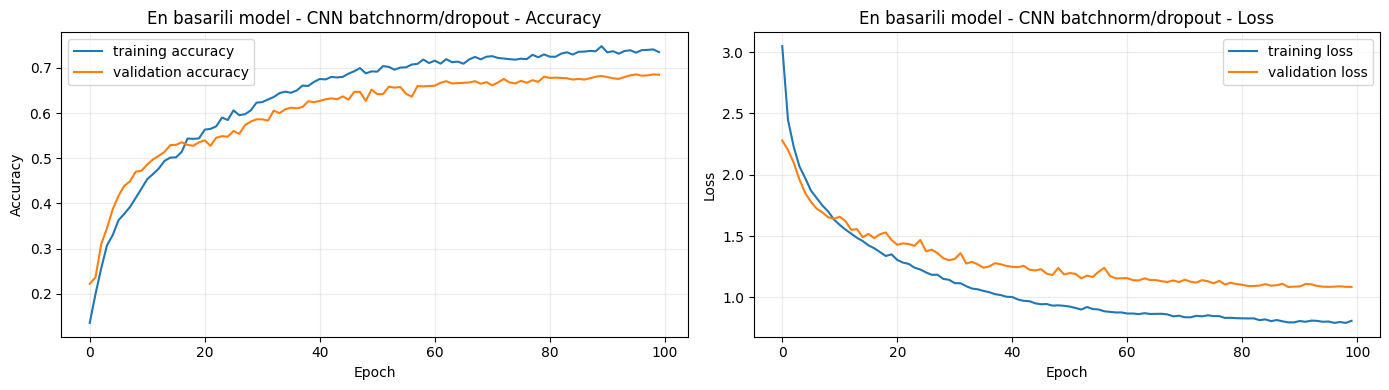

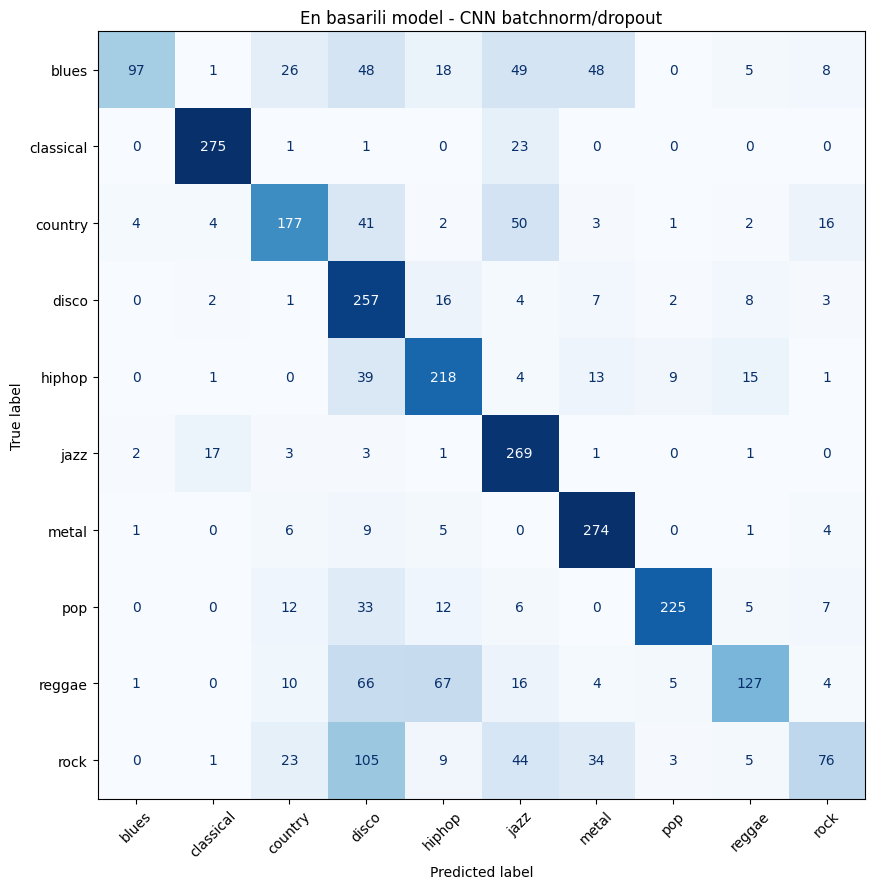

              precision    recall  f1-score   support

       blues       0.92      0.32      0.48       300
   classical       0.91      0.92      0.92       300
     country       0.68      0.59      0.63       300
       disco       0.43      0.86      0.57       300
      hiphop       0.63      0.73      0.67       300
        jazz       0.58      0.91      0.71       297
       metal       0.71      0.91      0.80       300
         pop       0.92      0.75      0.83       300
      reggae       0.75      0.42      0.54       300
        rock       0.64      0.25      0.36       300

    accuracy                           0.67      2997
   macro avg       0.72      0.67      0.65      2997
weighted avg       0.72      0.67      0.65      2997



In [6]:
EPOCHS = 100
BATCH_SIZE = 64
MODEL_BUILDERS = {
    "Onceki model - CNN baseline": build_cnn_baseline,
    "En basarili model - CNN batchnorm/dropout": build_cnn_best_candidate,
}

results = []
trained_models = {}
histories = {}

for model_name, builder in MODEL_BUILDERS.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    model = builder(input_shape)
    model.compile(optimizer=Adam(learning_rate=0.0001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    display(model.summary())
    callbacks = [
        EarlyStopping(monitor="val_accuracy", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(MODELS_DIR / f"{model.name}_checkpoint.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history = model.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val), batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=callbacks, verbose=2)
    train_loss, train_accuracy = model.evaluate(X_train_cnn, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(X_val_cnn, y_val, verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)
    y_pred = np.argmax(model.predict(X_test_cnn, verbose=0), axis=1)
    results.append({
        "model": model_name,
        "training_accuracy": train_accuracy,
        "validation_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "loss": train_loss,
        "validation_loss": val_loss,
        "test_loss": test_loss,
        "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "epochs_run": len(history.history["loss"]),
    })
    trained_models[model_name] = model
    histories[model_name] = history
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Validation accuracy: {val_accuracy:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")
    print(f"Loss: {train_loss:.4f}")
    print(f"Validation loss: {val_loss:.4f}")
    print(f"Test loss: {test_loss:.4f}")
    plot_history(history, model_name)
    show_confusion_matrix(model, X_test_cnn, y_test, model_name)

In [7]:
comparison_df = pd.DataFrame(results).sort_values("validation_accuracy", ascending=False).reset_index(drop=True)
display(comparison_df)
comparison_df.to_csv(MODELS_DIR / "model_comparison.csv", index=False, encoding="utf-8-sig")

best_model_name = comparison_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
best_model.save(MODELS_DIR / "best_model.keras")
best_model.save(MODELS_DIR / "best_model.h5")
print("En iyi model:", best_model_name)
print("Validation accuracy:", comparison_df.iloc[0]["validation_accuracy"])
print(MODELS_DIR / "best_model.keras")
print(MODELS_DIR / "best_model.h5")

,model,training_accuracy,validation_accuracy,test_accuracy,loss,validation_loss,test_loss,precision_macro,precision_weighted,recall_macro,recall_weighted,f1_macro,f1_weighted,epochs_run
0,Onceki model - CNN baseline,0.910619,0.70050,0.672339,0.307141,1.005854,1.044915,0.666812,0.666842,0.672508,0.672339,0.665656,0.665597,57
1,En basarili model - CNN batchnorm/dropout,0.727744,0.68549,0.665666,0.836549,1.085678,1.090095,0.717471,0.717611,0.665906,0.665666,0.650735,0.650680,100


En iyi model: Onceki model - CNN baseline
Validation accuracy: 0.7005003690719604
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\models\best_model.keras
C:\Users\Muham\Desktop\Data (1)\music-genre-classification\models\best_model.h5
